In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [3]:
df = pd.read_csv("/content/Sample - Superstore.csv", encoding="latin1")

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [4]:
df.shape

(9994, 21)

In [5]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [7]:
df.duplicated().sum()

np.int64(0)

In [9]:
df["Order Date"] = pd.to_datetime(df["Order Date"])

In [10]:
df["Order Date"].dtype

dtype('<M8[ns]')

In [11]:
df = df.sort_values("Order Date")

In [12]:
df[["Order Date", "Sales"]].head()

,Order Date,Sales
7980,2014-01-03,16.448
739,2014-01-04,11.784
740,2014-01-04,272.736
741,2014-01-04,3.540
1759,2014-01-05,19.536


In [13]:
monthly_sales = (
    df.set_index("Order Date")
      .resample("MS")["Sales"]
      .sum()
      .reset_index()
)

In [14]:
monthly_sales.head()

,Order Date,Sales
0,2014-01-01,14236.895
1,2014-02-01,4519.892
2,2014-03-01,55691.009
3,2014-04-01,28295.345
4,2014-05-01,23648.287


In [15]:
monthly_sales.tail()

,Order Date,Sales
43,2017-08-01,63120.8880
44,2017-09-01,87866.6520
45,2017-10-01,77776.9232
46,2017-11-01,118447.8250
47,2017-12-01,83829.3188


In [16]:
monthly_sales.shape

(48, 2)

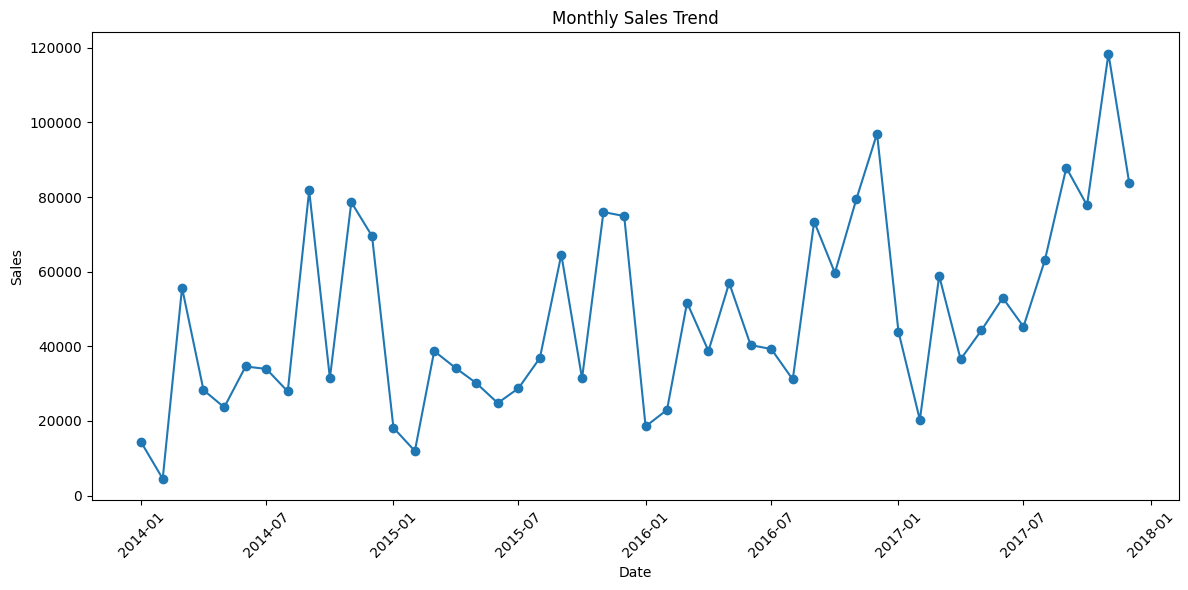

In [17]:
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_sales["Order Date"],
    monthly_sales["Sales"],
    marker="o"
)

plt.title("Monthly Sales Trend")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [18]:
monthly_sales["Month_Number"] = np.arange(len(monthly_sales))

In [19]:
monthly_sales["Month"] = monthly_sales["Order Date"].dt.month

In [20]:
monthly_sales.head()

,Order Date,Sales,Month_Number,Month
0,2014-01-01,14236.895,0,1
1,2014-02-01,4519.892,1,2
2,2014-03-01,55691.009,2,3
3,2014-04-01,28295.345,3,4
4,2014-05-01,23648.287,4,5


In [21]:
X = monthly_sales[["Month_Number", "Month"]]
y = monthly_sales["Sales"]

In [22]:
split = int(len(monthly_sales) * 0.8)

X_train = X.iloc[:split]
X_test = X.iloc[split:]

y_train = y.iloc[:split]
y_test = y.iloc[split:]

In [23]:
model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [24]:
y_pred = model.predict(X_test)

In [25]:
y_pred

array([37577.3681398 , 42433.54956466, 47289.73098951, 52145.91241437,
       57002.09383922, 61858.27526408, 66714.45668893, 71570.63811379,
       76426.81953864, 81283.0009635 ])

In [26]:
comparison = pd.DataFrame({
    "Date": monthly_sales["Order Date"].iloc[split:].values,
    "Actual Sales": y_test.values,
    "Predicted Sales": y_pred
})

comparison

,Date,Actual Sales,Predicted Sales
0,2017-03-01,58872.3528,37577.368140
1,2017-04-01,36521.5361,42433.549565
2,2017-05-01,44261.1102,47289.730990
3,2017-06-01,52981.7257,52145.912414
4,2017-07-01,45264.4160,57002.093839
5,2017-08-01,63120.8880,61858.275264
6,2017-09-01,87866.6520,66714.456689
7,2017-10-01,77776.9232,71570.638114
8,2017-11-01,118447.8250,76426.819539
9,2017-12-01,83829.3188,81283.000963


In [27]:
mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error:", mae)
print("Root Mean Squared Error:", rmse)
print("R² Score:", r2)

Mean Absolute Error: 11599.752647027708
Root Mean Squared Error: 17017.193217902462
R² Score: 0.4899519586746608


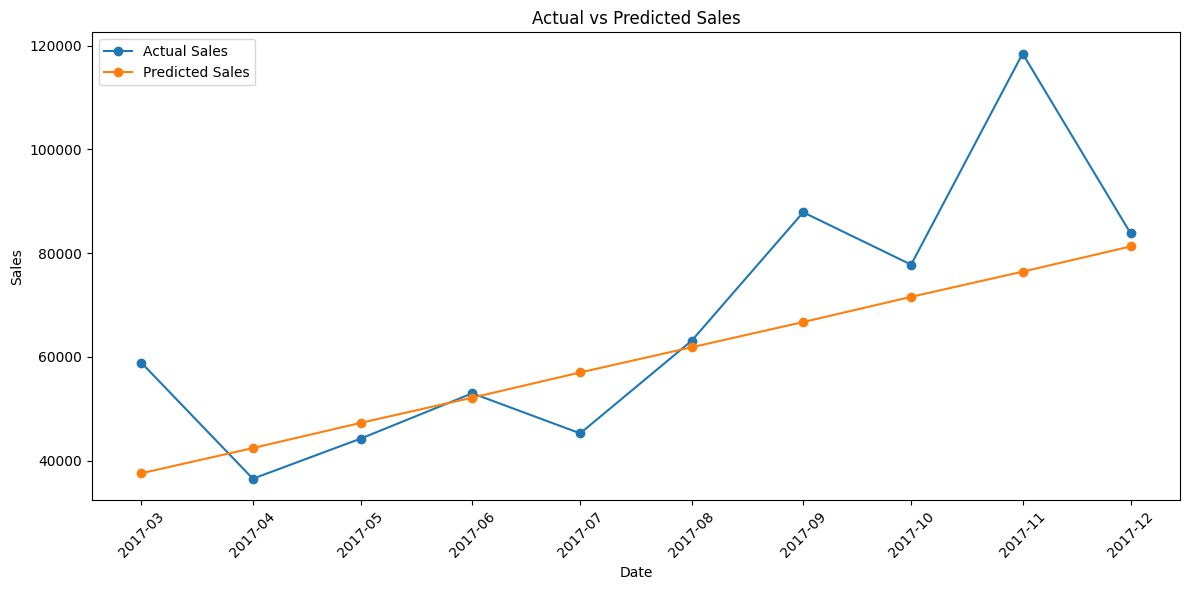

In [28]:
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_sales["Order Date"].iloc[split:],
    y_test,
    marker="o",
    label="Actual Sales"
)

plt.plot(
    monthly_sales["Order Date"].iloc[split:],
    y_pred,
    marker="o",
    label="Predicted Sales"
)

plt.title("Actual vs Predicted Sales")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [29]:
monthly_sales["Lag_1"] = monthly_sales["Sales"].shift(1)
monthly_sales["Lag_2"] = monthly_sales["Sales"].shift(2)
monthly_sales["Lag_3"] = monthly_sales["Sales"].shift(3)
monthly_sales["Lag_12"] = monthly_sales["Sales"].shift(12)

monthly_sales.head(15)

,Order Date,Sales,Month_Number,Month,Lag_1,Lag_2,Lag_3,Lag_12
0,2014-01-01,14236.8950,0,1,NaN,NaN,NaN,NaN
1,2014-02-01,4519.8920,1,2,14236.8950,NaN,NaN,NaN
2,2014-03-01,55691.0090,2,3,4519.8920,14236.8950,NaN,NaN
3,2014-04-01,28295.3450,3,4,55691.0090,4519.8920,14236.8950,NaN
4,2014-05-01,23648.2870,4,5,28295.3450,55691.0090,4519.8920,NaN
5,2014-06-01,34595.1276,5,6,23648.2870,28295.3450,55691.0090,NaN
6,2014-07-01,33946.3930,6,7,34595.1276,23648.2870,28295.3450,NaN
7,2014-08-01,27909.4685,7,8,33946.3930,34595.1276,23648.2870,NaN
8,2014-09-01,81777.3508,8,9,27909.4685,33946.3930,34595.1276,NaN
9,2014-10-01,31453.3930,9,10,81777.3508,27909.4685,33946.3930,NaN


In [30]:
monthly_sales_model = monthly_sales.dropna().copy()

In [31]:
monthly_sales_model.head()

,Order Date,Sales,Month_Number,Month,Lag_1,Lag_2,Lag_3,Lag_12
12,2015-01-01,18174.0756,12,1,69545.6205,78628.7167,31453.3930,14236.895
13,2015-02-01,11951.4110,13,2,18174.0756,69545.6205,78628.7167,4519.892
14,2015-03-01,38726.2520,14,3,11951.4110,18174.0756,69545.6205,55691.009
15,2015-04-01,34195.2085,15,4,38726.2520,11951.4110,18174.0756,28295.345
16,2015-05-01,30131.6865,16,5,34195.2085,38726.2520,11951.4110,23648.287


In [32]:
X = monthly_sales_model[
    ["Month_Number", "Month", "Lag_1", "Lag_2", "Lag_3", "Lag_12"]
]

y = monthly_sales_model["Sales"]

In [33]:
split = int(len(monthly_sales_model) * 0.8)

X_train = X.iloc[:split]
X_test = X.iloc[split:]

y_train = y.iloc[:split]
y_test = y.iloc[split:]

In [34]:
model_improved = LinearRegression()

model_improved.fit(X_train, y_train)

LinearRegression()

In [35]:
y_pred_improved = model_improved.predict(X_test)

In [36]:
mae_improved = mean_absolute_error(y_test, y_pred_improved)

rmse_improved = np.sqrt(
    mean_squared_error(y_test, y_pred_improved)
)

r2_improved = r2_score(y_test, y_pred_improved)

print("Improved Model Results")
print("----------------------")
print("MAE:", mae_improved)
print("RMSE:", rmse_improved)
print("R² Score:", r2_improved)

Improved Model Results
----------------------
MAE: 12331.389500269557
RMSE: 15878.820133990268
R² Score: 0.5524007709346024


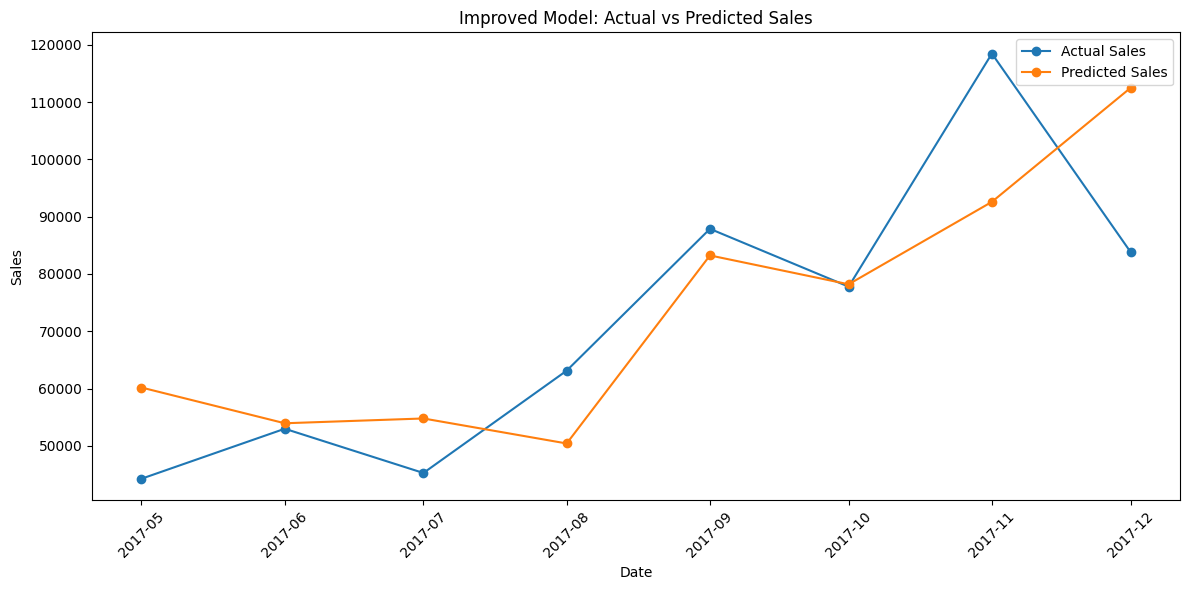

In [37]:
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_sales_model["Order Date"].iloc[split:],
    y_test,
    marker="o",
    label="Actual Sales"
)

plt.plot(
    monthly_sales_model["Order Date"].iloc[split:],
    y_pred_improved,
    marker="o",
    label="Predicted Sales"
)

plt.title("Improved Model: Actual vs Predicted Sales")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [38]:
monthly_sales["Year"] = monthly_sales["Order Date"].dt.year
monthly_sales["Month"] = monthly_sales["Order Date"].dt.month

In [39]:
monthly_sales["Time_Index"] = np.arange(len(monthly_sales))

In [40]:
seasonal_data = pd.get_dummies(
    monthly_sales,
    columns=["Month"],
    drop_first=True
)

In [41]:
seasonal_data.head()

,Order Date,Sales,Month_Number,Lag_1,Lag_2,Lag_3,Lag_12,Year,Time_Index,Month_2,Month_3,Month_4,Month_5,Month_6,Month_7,Month_8,Month_9,Month_10,Month_11,Month_12
0,2014-01-01,14236.895,0,NaN,NaN,NaN,NaN,2014,0,False,False,False,False,False,False,False,False,False,False,False
1,2014-02-01,4519.892,1,14236.895,NaN,NaN,NaN,2014,1,True,False,False,False,False,False,False,False,False,False,False
2,2014-03-01,55691.009,2,4519.892,14236.895,NaN,NaN,2014,2,False,True,False,False,False,False,False,False,False,False,False
3,2014-04-01,28295.345,3,55691.009,4519.892,14236.895,NaN,2014,3,False,False,True,False,False,False,False,False,False,False,False
4,2014-05-01,23648.287,4,28295.345,55691.009,4519.892,NaN,2014,4,False,False,False,True,False,False,False,False,False,False,False


In [42]:
feature_columns = [
    "Time_Index"
] + [col for col in seasonal_data.columns if col.startswith("Month_")]

X = seasonal_data[feature_columns]
y = seasonal_data["Sales"]

In [43]:
split = int(len(seasonal_data) * 0.8)

X_train = X.iloc[:split]
X_test = X.iloc[split:]

y_train = y.iloc[:split]
y_test = y.iloc[split:]

In [44]:
seasonal_model = LinearRegression()

seasonal_model.fit(X_train, y_train)

LinearRegression()

In [45]:
y_pred_seasonal = seasonal_model.predict(X_test)

In [46]:
mae_seasonal = mean_absolute_error(y_test, y_pred_seasonal)

rmse_seasonal = np.sqrt(
    mean_squared_error(y_test, y_pred_seasonal)
)

r2_seasonal = r2_score(y_test, y_pred_seasonal)

print("Seasonal Model Results")
print("---------------------")
print("MAE:", mae_seasonal)
print("RMSE:", rmse_seasonal)
print("R² Score:", r2_seasonal)

Seasonal Model Results
---------------------
MAE: 10797.080196666662
RMSE: 14420.71168471796
R² Score: 0.6337238739238589


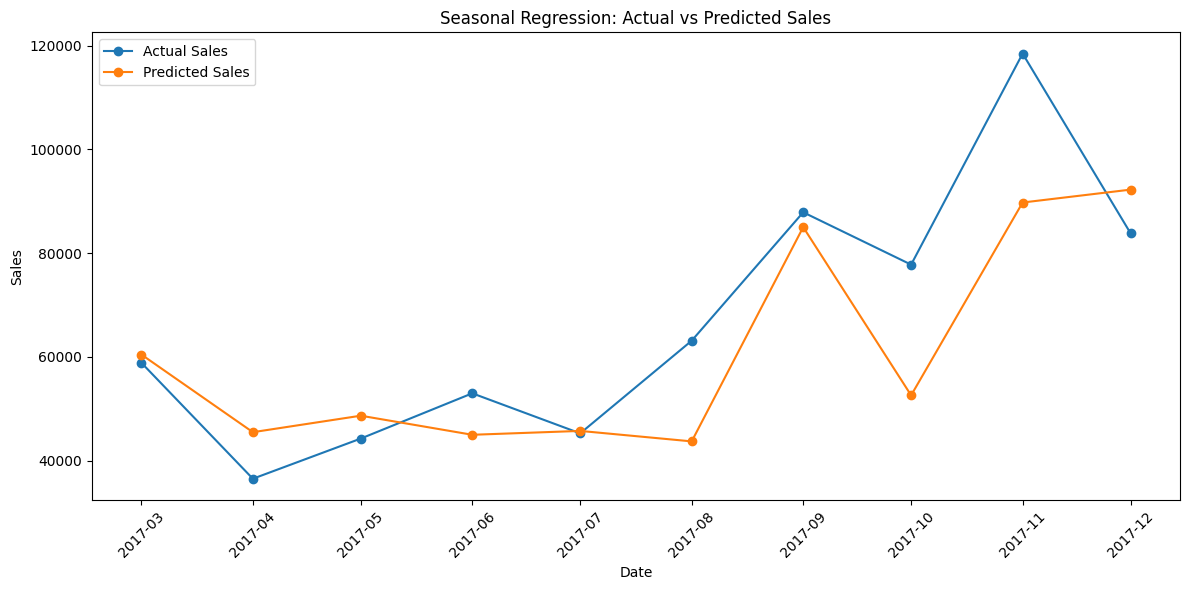

In [47]:
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_sales["Order Date"].iloc[split:],
    y_test,
    marker="o",
    label="Actual Sales"
)

plt.plot(
    monthly_sales["Order Date"].iloc[split:],
    y_pred_seasonal,
    marker="o",
    label="Predicted Sales"
)

plt.title("Seasonal Regression: Actual vs Predicted Sales")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [48]:
monthly_sales["Order Date"].max()

Timestamp('2017-12-01 00:00:00')

In [49]:
future_dates = pd.date_range(
    start=monthly_sales["Order Date"].max() + pd.DateOffset(months=1),
    periods=6,
    freq="MS"
)

future_dates

DatetimeIndex(['2018-01-01', '2018-02-01', '2018-03-01', '2018-04-01',
               '2018-05-01', '2018-06-01'],
              dtype='datetime64[ns]', freq='MS')

In [51]:
future_data = pd.DataFrame({
    "Order Date": future_dates
})

future_data["Time_Index"] = np.arange(
    len(monthly_sales),
    len(monthly_sales) + 6
)

future_data["Month"] = future_data["Order Date"].dt.month

future_data = pd.get_dummies(
    future_data,
    columns=["Month"],
    drop_first=True
)

In [52]:
future_data = future_data.reindex(
    columns=feature_columns,
    fill_value=False
)

In [53]:
future_data

,Time_Index,Month_Number,Month_2,Month_3,Month_4,Month_5,Month_6,Month_7,Month_8,Month_9,Month_10,Month_11,Month_12
0,48,False,False,False,False,False,False,False,False,False,False,False,False
1,49,False,True,False,False,False,False,False,False,False,False,False,False
2,50,False,False,True,False,False,False,False,False,False,False,False,False
3,51,False,False,False,True,False,False,False,False,False,False,False,False
4,52,False,False,False,False,True,False,False,False,False,False,False,False
5,53,False,False,False,False,False,True,False,False,False,False,False,False


In [54]:
future_predictions = seasonal_model.predict(future_data)

In [55]:
forecast = pd.DataFrame({
    "Date": future_dates,
    "Predicted Sales": future_predictions
})

forecast

,Date,Predicted Sales
0,2018-01-01,26667.293420
1,2018-02-01,17629.223660
2,2018-03-01,54093.866953
3,2018-04-01,38885.012077
4,2018-05-01,41816.041367
5,2018-06-01,37894.451690


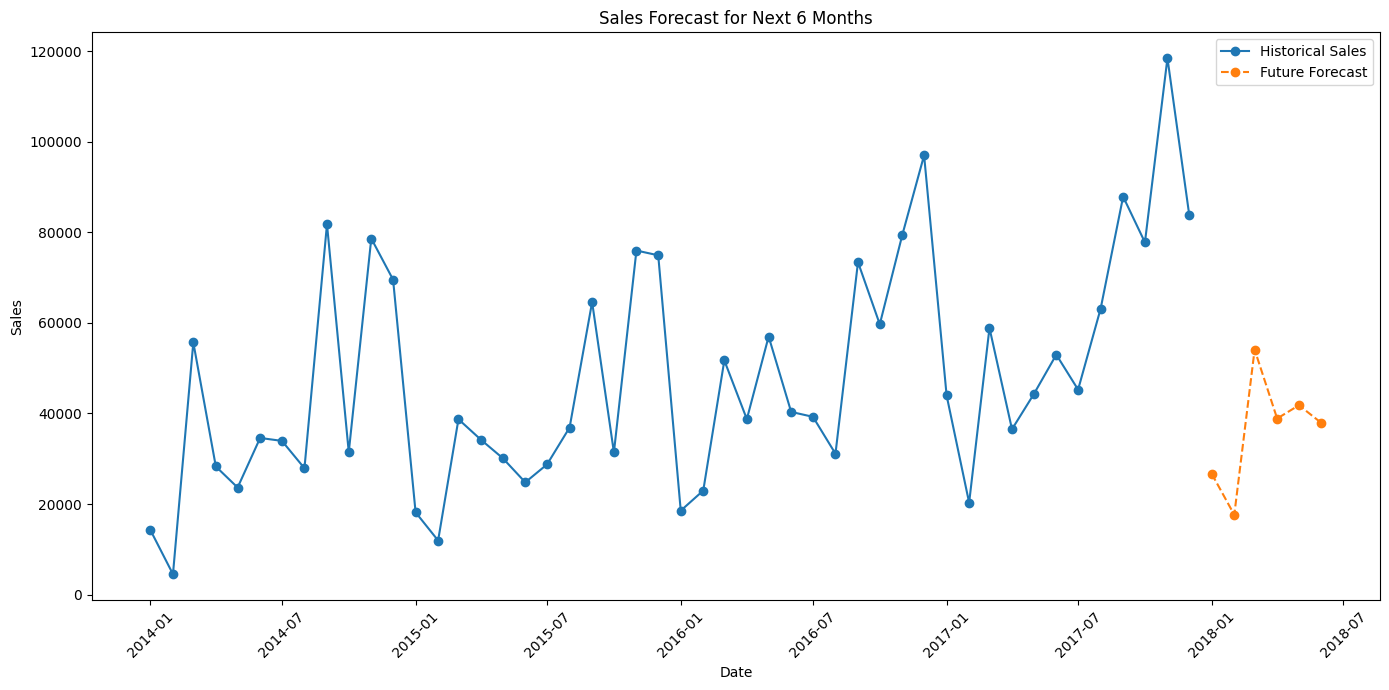

In [56]:
plt.figure(figsize=(14, 7))

plt.plot(
    monthly_sales["Order Date"],
    monthly_sales["Sales"],
    marker="o",
    label="Historical Sales"
)

plt.plot(
    forecast["Date"],
    forecast["Predicted Sales"],
    marker="o",
    linestyle="--",
    label="Future Forecast"
)

plt.title("Sales Forecast for Next 6 Months")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.legend()
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [57]:
forecast.to_csv(
    "sales_forecast.csv",
    index=False
)

In [58]:
from google.colab import files

files.download("sales_forecast.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [59]:
print("Last historical date:", monthly_sales["Order Date"].max())
print("Number of historical months:", len(monthly_sales))

Last historical date: 2017-12-01 00:00:00
Number of historical months: 48


In [60]:
future_dates = pd.date_range(
    start="2018-01-01",
    periods=6,
    freq="MS"
)

future_dates

DatetimeIndex(['2018-01-01', '2018-02-01', '2018-03-01', '2018-04-01',
               '2018-05-01', '2018-06-01'],
              dtype='datetime64[ns]', freq='MS')

In [61]:
future_data = pd.DataFrame({
    "Order Date": future_dates
})

future_data["Time_Index"] = np.arange(
    len(monthly_sales),
    len(monthly_sales) + 6
)

future_data["Month"] = future_data["Order Date"].dt.month

In [62]:
future_data = pd.get_dummies(
    future_data,
    columns=["Month"],
    drop_first=True
)

In [63]:
future_X = future_data.reindex(
    columns=feature_columns,
    fill_value=False
)

In [64]:
future_X

,Time_Index,Month_Number,Month_2,Month_3,Month_4,Month_5,Month_6,Month_7,Month_8,Month_9,Month_10,Month_11,Month_12
0,48,False,False,False,False,False,False,False,False,False,False,False,False
1,49,False,True,False,False,False,False,False,False,False,False,False,False
2,50,False,False,True,False,False,False,False,False,False,False,False,False
3,51,False,False,False,True,False,False,False,False,False,False,False,False
4,52,False,False,False,False,True,False,False,False,False,False,False,False
5,53,False,False,False,False,False,True,False,False,False,False,False,False


In [65]:
future_predictions = seasonal_model.predict(future_X)

In [66]:
forecast = pd.DataFrame({
    "Date": future_dates,
    "Predicted Sales": future_predictions
})

forecast

,Date,Predicted Sales
0,2018-01-01,26667.293420
1,2018-02-01,17629.223660
2,2018-03-01,54093.866953
3,2018-04-01,38885.012077
4,2018-05-01,41816.041367
5,2018-06-01,37894.451690


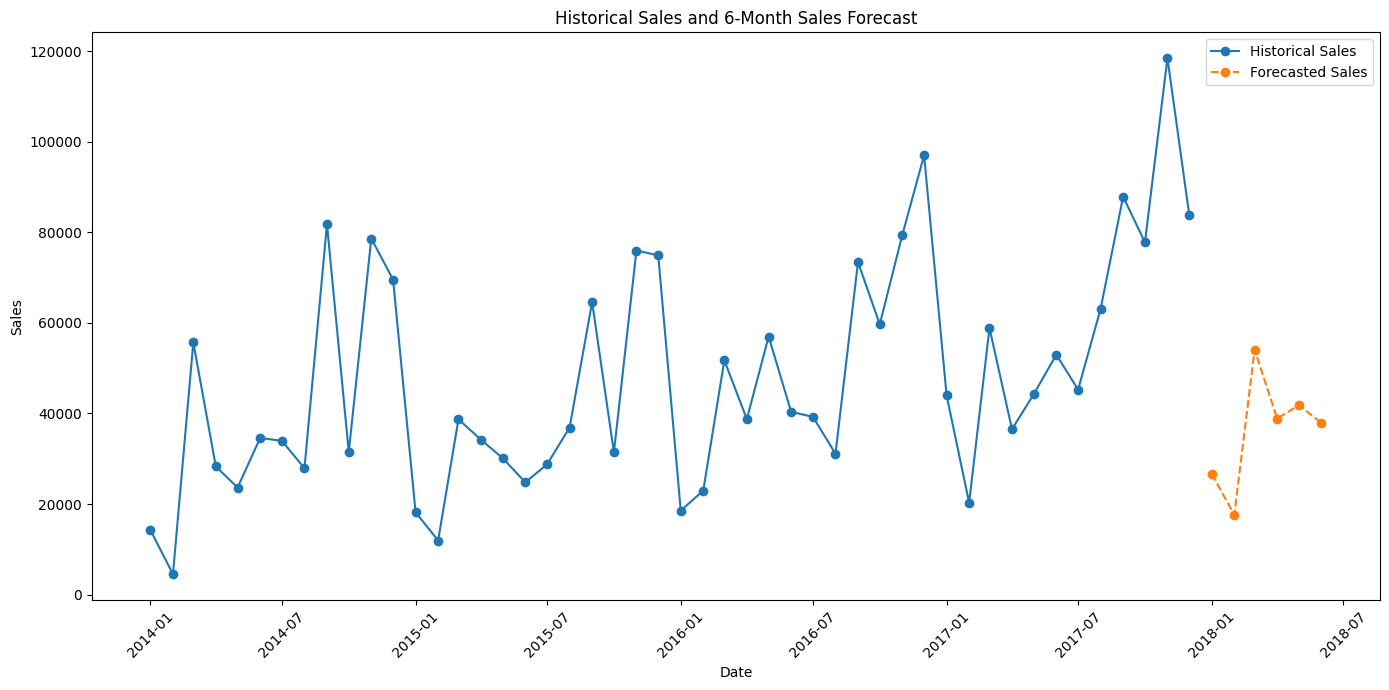

In [67]:
plt.figure(figsize=(14, 7))

plt.plot(
    monthly_sales["Order Date"],
    monthly_sales["Sales"],
    marker="o",
    label="Historical Sales"
)

plt.plot(
    forecast["Date"],
    forecast["Predicted Sales"],
    marker="o",
    linestyle="--",
    label="Forecasted Sales"
)

plt.title("Historical Sales and 6-Month Sales Forecast")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.legend()
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [68]:
forecast.to_csv(
    "sales_forecast_2018.csv",
    index=False
)

In [69]:
from google.colab import files

files.download("sales_forecast_2018.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [70]:
forecast


,Date,Predicted Sales
0,2018-01-01,26667.293420
1,2018-02-01,17629.223660
2,2018-03-01,54093.866953
3,2018-04-01,38885.012077
4,2018-05-01,41816.041367
5,2018-06-01,37894.451690


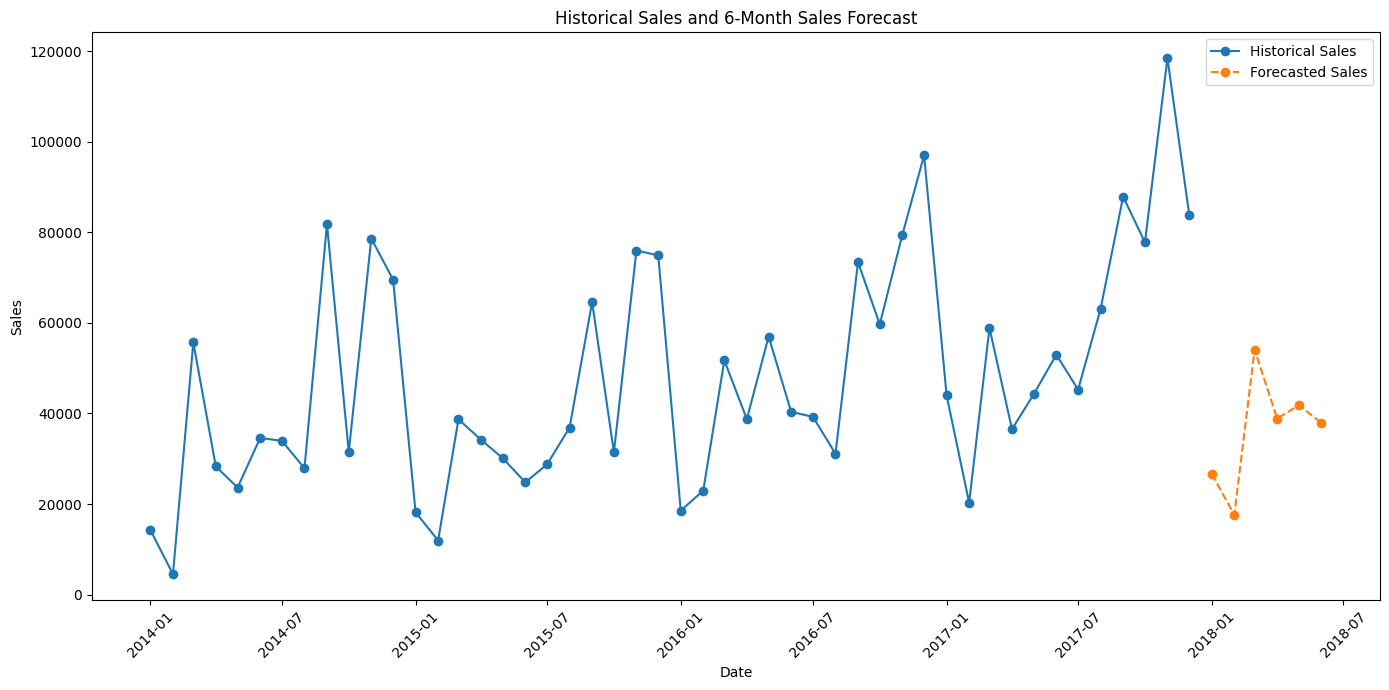

In [71]:
plt.figure(figsize=(14, 7))

plt.plot(
    monthly_sales["Order Date"],
    monthly_sales["Sales"],
    marker="o",
    label="Historical Sales"
)

plt.plot(
    forecast["Date"],
    forecast["Predicted Sales"],
    marker="o",
    linestyle="--",
    label="Forecasted Sales"
)

plt.title("Historical Sales and 6-Month Sales Forecast")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.legend()
plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig("sales_forecast.png", dpi=300, bbox_inches="tight")

plt.show()

In [72]:
model_comparison = pd.DataFrame({
    "Model": [
        "Basic Linear Regression",
        "Lag Regression",
        "Seasonal Regression"
    ],
    "MAE": [
        11599.752647,
        12331.389500,
        10797.080197
    ],
    "RMSE": [
        17017.193220,
        15878.820134,
        14420.711685
    ],
    "R2 Score": [
        0.489952,
        0.552401,
        0.633724
    ]
})

model_comparison

,Model,MAE,RMSE,R2 Score
0,Basic Linear Regression,11599.752647,17017.193220,0.489952
1,Lag Regression,12331.389500,15878.820134,0.552401
2,Seasonal Regression,10797.080197,14420.711685,0.633724


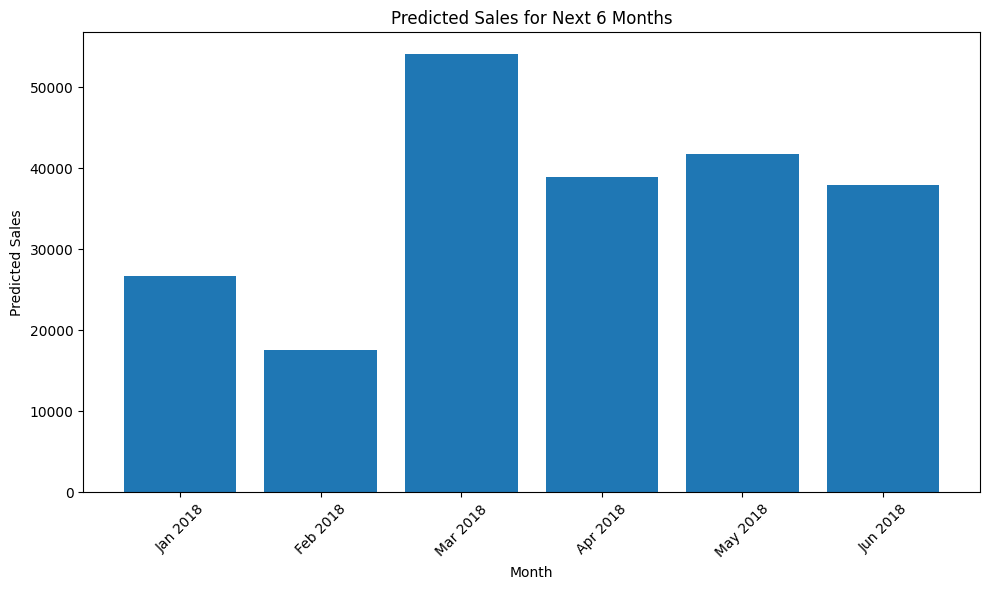

In [73]:
plt.figure(figsize=(10, 6))

plt.bar(
    forecast["Date"].dt.strftime("%b %Y"),
    forecast["Predicted Sales"]
)

plt.title("Predicted Sales for Next 6 Months")
plt.xlabel("Month")
plt.ylabel("Predicted Sales")

plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig("future_sales_forecast.png", dpi=300, bbox_inches="tight")

plt.show()

## Conclusion

This project analyzed historical sales data from the Superstore dataset to develop a predictive model for future sales forecasting.

The transaction-level data was cleaned and preprocessed by checking for missing values and duplicate records, converting order dates into datetime format, sorting the data chronologically, and aggregating sales into monthly totals.

Three regression approaches were evaluated: Basic Linear Regression, Lag-feature Regression, and Seasonal Regression. The Seasonal Regression model performed best, achieving an R² score of approximately 0.634, with an MAE of approximately 10,797 and RMSE of approximately 14,421.

The selected model was then used to forecast sales for the next six months from January 2018 to June 2018.

The analysis demonstrates how historical sales patterns, time trends, and seasonal behavior can be used to support data-driven sales forecasting and business decision-making.

## Key Insights

- Historical sales show an overall upward trend over the analyzed period.
- Monthly sales fluctuate considerably, indicating the presence of seasonal patterns.
- Some months consistently show higher sales than others.
- Seasonal Regression performed better than the basic and lag-based regression models.
- The model achieved an R² score of approximately 63.4%, indicating that the selected features explain a substantial portion of the variation in monthly sales.
- The forecast indicates that future monthly sales are expected to continue fluctuating rather than following a perfectly linear trend.
- Sales forecasts can help businesses plan inventory, resources, marketing activities, and future sales strategies.